In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

![fig3](C:/Users/henri/OneDrive%20-%20Aarhus%20universitet/2.%20Semester/Numerisk%20Lineær%20Algebra/TØ/Opgavesæt%2013/Billeder/fig3.png)

$$
% uncomment det her hvis man vil se billedet rendered
% ![fig3](Billeder/fig3.png)
$$

To beholder er forbundne med rør, som i figur 3. Beholder $A$ rummer 300 l og beholder $B$ 100 l. Som udgangspunkt er der 90 g salt i beholder $A$ og 30 g salt i beholder $B$. Der tilføjes 30,0 l/min rent vand igennem rør $a$ og der flyder 15,0 l/min blanding igennem rør $b$.

## (a) Hvor meget blanding skal flyde igennem rør $c$ per minut, hvis væskemængden i beholderen $A$ skal være konstant? Hvor meget skal flyde ud igennem rør $d$, for at væskemængden i $B$ er konstant? {-}

Hvis væskemængden skal være konstant skal der blot flyde lige så meget ud som ind. Det er derfor bare summen af tilføjelsen i $A$ og $B$ som skal flyde ud af $C$.
\begin{align*}
a_{flow} + b_{flow} & = c_{flow} \\
30.0 \text{ l/min} + 15.0 \text{ l/min} & = 45.0 \text{ l/min}
\end{align*}

For $d$ er det igen det samme, men nu vil "tilføjelsen" fra $b$ være negativ, da det flyder ud:
\begin{align*}
c_{flow} - b_{flow} & = d_{flow} \\
45.0 \text{ l/min} - 15.0 \text{ l/min} & = 30.0 \text{ l/min}
\end{align*}

$\pagebreak$

## (b) Gør rede for at saltmængderne $y_{0}(t)$ i $A$ og $y_{1}(t)$ i 𝐵 opfylder systemet {-}

\begin{equation}
\tag{13.1}
\begin{array}{l}
y_{0}'(t) = - 0.15 y_{0}(t) + 0.15 y_{1}(t)\\
y_{1}'(t) = 0.15 y_{0}(t) - 0.15 y_{1}(t)
\end{array}
\end{equation}

Saltmængden af $A$ og $B$ måles i gram, og da $y_{0}'(t)$ og $y_{1}'(t)$ er ændringen i dem, må de måles i gram pr. minut. Faktorerne som bliver ganget på $y_{0}(t)$ og $y_{1}(t)$, må da svare til væksten pr. minut (målt i $\text{min}^{-1}$) fra hver beholder.

I beholder $A$ er væksten fra sig selv svarende til mængden af salt der flyder ud, hvilket er mængden af blanding gennem rør $c$ delt med volumenet af beholder $A$:
$$
-\frac{c_{flow}}{V_{A}} = -\frac{45.0 \text{ l/min}}{300 \text{ l}} = -0.15 \text{ min}^{-1}
$$

Det kan ses at både værdien og enhederne går op med det givne system. Beregnes det for de andre værdier kan det ses, at de også passer:
$$
\frac{b_{flow}}{V_{B}} = \frac{15.0 \text{ l/min}}{100 \text{ l}} = 0.15 \text{ min}^{-1}
$$
$$
\frac{c_{flow}}{V_{A}} = \frac{45.0 \text{ l/min}}{300 \text{ l}} = 0.15 \text{ min}^{-1}
$$
$$
- \frac{b_{flow}}{V_{B}} - \frac{d_{flow}}{V_{B}} = -\frac{15.0 \text{ l/min}}{100 \text{ l}} - \frac{30.0 \text{ l/min}}{100 \text{ l}} = -0.45 \text{ min}^{-1}
$$
Dette system passer da perfekt med saltmængderne i $A$ og $B$ samt ændringer i dem.

$\pagebreak$

## (c) I python beregn egenværdier og egenvektorer for koefficientmatricen for systemet (13.1). {-}

Variablerne i systemet er $\begin{bmatrix} y_{0}(t) \\ y_{1}(t) \end{bmatrix}$, så koefficientmatricen ender med at være
$$
A = 
\begin{bmatrix}
-0.15 & 0.15 \\
0.15 & -0.45
\end{bmatrix}
$$

Det karakteristiske polynomium kan da opstilles således:
\begin{align*}
\text{det}(A - \lambda I_{2})
 & = \text{det} \left(\begin{bmatrix}
-0.15 - \lambda & 0.15 \\
0.15 & - 0.45 - \lambda
\end{bmatrix}\right) \\
 & = (- 0.15 - \lambda) (- 0.45 - \lambda) - 0.15 \cdot 0.15 \\
 & = 0.0675 + 0.15 \lambda + 0.45 \lambda + \lambda^{2} - 0.0225 \\
 & = \lambda^{2} + 0.6 \lambda + 0.045\\
\end{align*}

Egenvektorerne for $A$ kan findes ved at løse ligningssystemet $(A - \lambda I_{2}) v = 0$ for hver egenværdi.

In [3]:
# Rødderne af det karakteristiske polynomium (egenværdierne) findes vha. numpy
lambda_0, lambda_1 = np.roots([1, 0.6, 0.045])
lambda_0, lambda_1

(-0.5121320343559642, -0.08786796564403575)

$$
(A - \lambda_{0} I_{2}) v_{0} = 0
$$

In [4]:
# Opsætter koefficientmatrix i python
A = np.array([  [-0.15, 0.15],
                [0.15, -0.45]])

# Ligning sættes op for egenværdien lambda_0
ligning0 = A - lambda_0 * np.eye(2)

# Rækkeoperationer bruges for at forsimple ligningen
ligning0[0] *= 1 / ligning0[0,0]
ligning0[1] -= 0.15 * ligning0[0]
np.round(ligning0, 4)   # Afrunding for at få læsbar tal

array([[ 1.    ,  0.4142],
       [ 0.    , -0.    ]])

Ud fra dette kan følgende ligning opstilles:
$$
x_{0} + 0.414 y_{0} = 0
$$

Hvor en løsning ville være:
$$
v_{0} =
\begin{bmatrix}
x_{0} \\
y_{0}
\end{bmatrix} =
\begin{bmatrix}
1 \\
-\frac{1}{0.414}
\end{bmatrix}
$$

In [5]:
x_0 = ligning0[0,0]
y_0 = - x_0 / ligning0[0,1]

v_0 = np.array([x_0, y_0])[:, np.newaxis]
v_0

array([[ 1.        ],
       [-2.41421356]])

Denne proces gentages for den anden egenværdi.

In [6]:
ligning1 = A - lambda_1 * np.eye(2)
ligning1[0] *= 1/ligning1[0,0]
ligning1[1] -= 0.15 * ligning1[0]
np.round(ligning1, 4)

array([[ 1.    , -2.4142],
       [ 0.    ,  0.    ]])

In [7]:
x_1 = ligning1[0,0]
y_1 = - x_1 / ligning1[0,1]

v_1 = np.array([x_1, y_1])[:, np.newaxis]
v_1

array([[1.        ],
       [0.41421356]])

$\pagebreak$

## (d) Brug de fundne egenværdier og egenvektorer til at bestemme løsninger $y_{0}(t)$ og $y_{1}(𝑡)$ med det givne startdata. {-}

Der opstilles en ligning ud fra startværdien som forneden for at bestemme konstanterne $c_{0}$ og $c_{1}$.
$$
y(0) = c_{0} v_{0} + c_{1} v_{1} =
\begin{bmatrix}
90 \\
30
\end{bmatrix}
$$

In [8]:
# Opstilling af ligningen
b = np.array([  [90],
                [30]])
ligning = np.column_stack((v_0, v_1, b))
ligning

array([[ 1.        ,  1.        , 90.        ],
       [-2.41421356,  0.41421356, 30.        ]])

In [9]:
# Rækkeoperationer for at løse systemet
ligning[1] -= ligning[0] * ligning[1,0]
ligning[1] *= 1 / ligning[1,1]
ligning[0] -= ligning[1]
np.round(ligning, 4)

array([[ 1.    , -0.    ,  2.5736],
       [ 0.    ,  1.    , 87.4264]])

In [10]:
c_0, c_1 = ligning[:, 2]
c_0, c_1

(2.5735931288071328, 87.42640687119287)

Løsningerne til hhv. $y_{0}(t)$ og $y_{1}(t)$ bliver dermed
$$
y_{0}(t) = 2.57 \cdot 1.00 \cdot e^{-0.51 t} + 87.43 \cdot 1.00 \cdot e^{-0.088 t}
$$
$$
y_{1}(t) = 2.57 \cdot -2.41 \cdot e^{-0.51 t} + 87.43 \cdot 0.41 \cdot e^{-0.088 t}
$$

## (e) Plot funktionerne $y_{0}(t)$ og $y_{1}(t)$ mod $t$ og lav også et plot af $y_{0}(t)$ mod $y_{1}(t)$. {-}

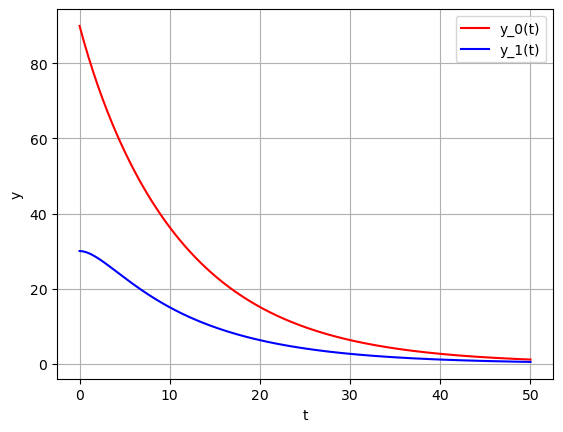

In [11]:
# Opstiller t-værdierne for en arbitrær definitionsmængde 
t = np.linspace(0, 50, 200)

# Opstiller løsningerne fra forrige opgave
y_0 = c_0 * v_0[0] * np.exp(lambda_0 * t) + c_1 * v_1[0] * np.exp(lambda_1 * t)
y_1 = c_0 * v_0[1] * np.exp(lambda_0 * t) + c_1 * v_1[1] * np.exp(lambda_1 * t)

# Plotter t op i mod hhv. y_0 og y_1
fig, ax = plt.subplots()
ax.plot(t, y_0, 'r', label='y_0(t)')
ax.plot(t, y_1, 'b', label='y_1(t)')
plt.xlabel("t")
plt.ylabel("y")
ax.legend()
ax.grid()

Text(0, 0.5, 'y_1(t)')

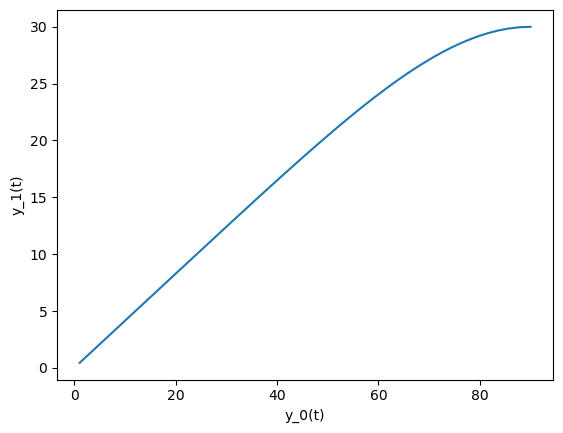

In [12]:
# Plotter y_0 op i mod y_1
fig, ax = plt.subplots()
ax.plot(y_0, y_1)
plt.xlabel("y_0(t)")
plt.ylabel("y_1(t)")

## (f) Hvad er grænseværdien for $y_{1}(t) / y_{0} (t)$ når $t \to ∞$? {-}

Grænseværdien kommer til at være følgende:
$$
\lim_{ t \to \infty } \frac{2.57 \cdot e^{-0.51 \cdot t} + 87.43 \cdot e^{-0.088 \cdot t}}{2.57 \cdot (-2.41) \cdot e^{-0.51 \cdot t} + 87.43 \cdot 0.41 \cdot e^{-0.088 \cdot t}}
$$
Når t går mod uendelig vil eksponentialfunktionerne gå mod 0, da de er opløftet i noget negativt ganget med t. Da både tæller og nævner går mod 0 vil det lede til L'Hopital, hvilket vil beregnes med sympy forneden.

In [13]:
t = sp.symbols('t')
y_0 = 2.57 * sp.exp(-0.51 * t) + 87.43 * sp.exp(-0.088 * t)
y_1 = 2.57 * (-2.41) * sp.exp(-0.51 * t) + 87.43 * 0.41 * sp.exp(-0.088 * t)
lhopital = y_1/y_0
sp.limit(lhopital, t, sp.oo)

41/100

Grænseværdien for $y_{1}(t)/y_{0}(t)$ når $t \to \infty$ vil da være 0.41.